# Forward & Inverse Kinematics
## A Complete Tutorial from Homogeneous Transforms to Numerical IK

This notebook provides a self-contained, from-scratch implementation of **forward and inverse kinematics** for serial robotic manipulators. We build every component from first principles: rotation matrices, DH parameters, the geometric Jacobian, analytical and numerical inverse kinematics, and singularity analysis.

**What you'll learn:**
1. Homogeneous transformations and their composition for rigid-body motion
2. The Denavit-Hartenberg convention for describing kinematic chains
3. Forward kinematics: computing end-effector pose from joint angles
4. The geometric Jacobian and its role in differential kinematics
5. Analytical inverse kinematics for planar arms (elbow-up/elbow-down)
6. Numerical IK via Newton-Raphson and Damped Least Squares
7. Singularity analysis, manipulability ellipsoids, and workspace visualization

**Prerequisites:** Linear algebra (matrix multiplication, eigenvalues), trigonometry, basic calculus.

**References:**
- Craig, *Introduction to Robotics: Mechanics and Control*, 4th ed., Pearson, 2018.
- Siciliano et al., *Robotics: Modelling, Planning and Control*, Springer, 2009.

---
## 1. What is Kinematics?

Kinematics is the study of motion **without considering forces**. For a robotic manipulator — a chain of rigid links connected by joints — there are two fundamental problems:

| Problem | Input | Output | Difficulty |
|---------|-------|--------|------------|
| **Forward Kinematics (FK)** | Joint angles $\mathbf{q} \in \mathbb{R}^n$ | End-effector pose $(\mathbf{p}, \mathbf{R}) \in SE(3)$ | Easy (unique solution) |
| **Inverse Kinematics (IK)** | Desired end-effector pose | Joint angles $\mathbf{q}$ | Hard (multiple or no solutions) |

The forward kinematics map is a smooth function:

$$\mathbf{T}(\mathbf{q}) : \mathbb{R}^n \to SE(3)$$

where $SE(3)$ is the Special Euclidean group — the space of rigid-body transformations in 3D. Forward kinematics is always well-defined (just multiply matrices), but inverse kinematics is fundamentally harder:

- **Non-uniqueness:** multiple joint configurations can produce the same end-effector pose (e.g., elbow-up vs. elbow-down)
- **Non-existence:** some poses lie outside the reachable workspace
- **Singularities:** at certain configurations, the robot loses degrees of freedom

The **Jacobian** $\mathbf{J}(\mathbf{q})$ bridges these two problems. It maps joint velocities to end-effector velocities:

$$\dot{\mathbf{x}} = \mathbf{J}(\mathbf{q}) \, \dot{\mathbf{q}}$$

and its (pseudo)inverse enables iterative numerical IK.

---
## 2. Homogeneous Transformations

### Rotation Matrices

A rotation matrix $\mathbf{R} \in SO(3)$ satisfies $\mathbf{R}^T \mathbf{R} = \mathbf{I}$ and $\det(\mathbf{R}) = 1$. The elementary rotations about the coordinate axes are:

$$R_x(\theta) = \begin{pmatrix} 1 & 0 & 0 \\ 0 & \cos\theta & -\sin\theta \\ 0 & \sin\theta & \cos\theta \end{pmatrix}, \quad R_y(\theta) = \begin{pmatrix} \cos\theta & 0 & \sin\theta \\ 0 & 1 & 0 \\ -\sin\theta & 0 & \cos\theta \end{pmatrix}, \quad R_z(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

### Homogeneous Transformation Matrices

A rigid-body transformation (rotation + translation) is compactly represented as a $4 \times 4$ **homogeneous transformation matrix:**

$$\boxed{\mathbf{T} = \begin{pmatrix} \mathbf{R} & \mathbf{p} \\ \mathbf{0}^T & 1 \end{pmatrix} \in SE(3)}$$

where $\mathbf{R} \in SO(3)$ is the rotation and $\mathbf{p} \in \mathbb{R}^3$ is the translation.

**Key property:** Composition of transformations is matrix multiplication:

$${}^{0}\mathbf{T}_2 = {}^{0}\mathbf{T}_1 \cdot {}^{1}\mathbf{T}_2$$

This allows us to chain transforms along a kinematic chain to get the end-effector pose.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

In [ ]:
# =============================================================================
# Global Constants
# =============================================================================

# 3R planar arm link lengths
L1 = 1.0
L2 = 0.8
L3 = 0.5

# Numerical differentiation
FD_EPSILON = 1e-7

# IK parameters
IK_MAX_ITER = 100
IK_TOL = 1e-6
DLS_LAMBDA = 0.01

# Workspace sampling
N_WORKSPACE_SAMPLES = 50

# Visualization colors
COLOR_LINK = 'steelblue'
COLOR_JOINT = 'coral'
COLOR_EE = 'seagreen'
COLOR_TARGET = 'crimson'
COLOR_FRAME_X = 'red'
COLOR_FRAME_Y = 'green'
COLOR_FRAME_Z = 'blue'

In [ ]:
def rot_x(theta):
    """Rotation matrix about the x-axis.

    Args:
        theta: Rotation angle in radians. Scalar.

    Returns:
        3x3 rotation matrix. Shape: (3, 3).
    """
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [1, 0,  0],
        [0, c, -s],
        [0, s,  c]
    ])


def rot_y(theta):
    """Rotation matrix about the y-axis.

    Args:
        theta: Rotation angle in radians. Scalar.

    Returns:
        3x3 rotation matrix. Shape: (3, 3).
    """
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [ c, 0, s],
        [ 0, 1, 0],
        [-s, 0, c]
    ])


def rot_z(theta):
    """Rotation matrix about the z-axis.

    Args:
        theta: Rotation angle in radians. Scalar.

    Returns:
        3x3 rotation matrix. Shape: (3, 3).
    """
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ])


def homogeneous_transform(R, p):
    """Build a 4x4 homogeneous transformation matrix.

    Args:
        R: Rotation matrix. Shape: (3, 3).
        p: Translation vector. Shape: (3,).

    Returns:
        4x4 homogeneous transform. Shape: (4, 4).
    """
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = p
    return T

In [ ]:
# ---- Verification: Rotation Matrix Properties ----
angles_test = [0.3, -1.2, 2.7]
for name, R_func in [('Rx', rot_x), ('Ry', rot_y), ('Rz', rot_z)]:
    for theta in angles_test:
        R = R_func(theta)
        # Check R @ R.T = I
        orth_err = np.max(np.abs(R @ R.T - np.eye(3)))
        # Check det(R) = 1
        det_err = abs(np.linalg.det(R) - 1.0)
        status = "PASS" if (orth_err < 1e-12 and det_err < 1e-12) else "FAIL"
        print(f"{name}({theta:+.1f}): orthogonality err = {orth_err:.2e}, det err = {det_err:.2e} [{status}]")

# Check composition: Rz(a) @ Rz(b) = Rz(a+b)
a, b = 0.5, 1.3
comp_err = np.max(np.abs(rot_z(a) @ rot_z(b) - rot_z(a + b)))
status_comp = "PASS" if comp_err < 1e-12 else "FAIL"
print(f"\nComposition Rz(a)@Rz(b)=Rz(a+b): max error = {comp_err:.2e} [{status_comp}]")

Rx(+0.3): orthogonality err = 1.11e-16, det err = 1.11e-16 [PASS]
Rx(-1.2): orthogonality err = 1.11e-16, det err = 1.11e-16 [PASS]
Rx(+2.7): orthogonality err = 6.34e-18, det err = 0.00e+00 [PASS]
Ry(+0.3): orthogonality err = 1.11e-16, det err = 1.11e-16 [PASS]
Ry(-1.2): orthogonality err = 1.11e-16, det err = 1.11e-16 [PASS]
Ry(+2.7): orthogonality err = 6.34e-18, det err = 0.00e+00 [PASS]
Rz(+0.3): orthogonality err = 1.11e-16, det err = 1.11e-16 [PASS]
Rz(-1.2): orthogonality err = 1.11e-16, det err = 1.11e-16 [PASS]
Rz(+2.7): orthogonality err = 6.34e-18, det err = 0.00e+00 [PASS]

Composition Rz(a)@Rz(b)=Rz(a+b): max error = 1.11e-16 [PASS]


---
## 3. Denavit-Hartenberg Parameters

The **Denavit-Hartenberg (DH) convention** provides a systematic way to attach coordinate frames to each link of a serial manipulator, using only **4 parameters** per joint:

| Parameter | Symbol | Description |
|-----------|--------|-------------|
| Link length | $a_i$ | Distance along $x_i$ from $z_{i-1}$ to $z_i$ |
| Link twist | $\alpha_i$ | Angle about $x_i$ from $z_{i-1}$ to $z_i$ |
| Link offset | $d_i$ | Distance along $z_{i-1}$ from $x_{i-1}$ to $x_i$ |
| Joint angle | $\theta_i$ | Angle about $z_{i-1}$ from $x_{i-1}$ to $x_i$ |

For a **revolute** joint, $\theta_i$ is the variable and $(a_i, \alpha_i, d_i)$ are fixed. For a **prismatic** joint, $d_i$ is the variable.

The transformation from frame $i-1$ to frame $i$ is:

$$\boxed{{}^{i-1}\mathbf{T}_i = R_z(\theta_i) \cdot T_z(d_i) \cdot T_x(a_i) \cdot R_x(\alpha_i) = \begin{pmatrix} \cos\theta_i & -\sin\theta_i \cos\alpha_i & \sin\theta_i \sin\alpha_i & a_i \cos\theta_i \\ \sin\theta_i & \cos\theta_i \cos\alpha_i & -\cos\theta_i \sin\alpha_i & a_i \sin\theta_i \\ 0 & \sin\alpha_i & \cos\alpha_i & d_i \\ 0 & 0 & 0 & 1 \end{pmatrix}}$$

In [ ]:
def dh_transform(a, alpha, d, theta):
    """Build the 4x4 DH transformation matrix for one joint.

    Implements the standard DH convention:
        T = Rz(theta) * Tz(d) * Tx(a) * Rx(alpha)

    Args:
        a: Link length. Scalar.
        alpha: Link twist (radians). Scalar.
        d: Link offset. Scalar.
        theta: Joint angle (radians). Scalar.

    Returns:
        4x4 DH transformation matrix. Shape: (4, 4).
    """
    ct = np.cos(theta)
    st = np.sin(theta)
    ca = np.cos(alpha)
    sa = np.sin(alpha)
    return np.array([
        [ct, -st * ca,  st * sa, a * ct],
        [st,  ct * ca, -ct * sa, a * st],
        [ 0,       sa,       ca,      d],
        [ 0,        0,        0,      1]
    ])

In [ ]:
# ---- DH Tables ----

# 3R Planar Arm: all joints rotate about z, all motion in the xy-plane
# Format: each row is (a, alpha, d) -- theta is the joint variable
DH_3R_PLANAR = np.array([
    [L1, 0, 0],  # Joint 1
    [L2, 0, 0],  # Joint 2
    [L3, 0, 0],  # Joint 3
])

# 6-DOF Spatial Arm (anthropomorphic: 3R shoulder/elbow + 3R spherical wrist)
# Similar to a simplified Puma 560 configuration
# Format: each row is (a, alpha, d) -- theta is the joint variable
D1 = 0.4    # base height
A2 = 0.8    # upper arm length
A3 = 0.3    # elbow offset
D4 = 0.8    # forearm length
D6 = 0.2    # tool length

DH_6DOF = np.array([
    [0,   np.pi/2,  D1],  # Joint 1: base rotation
    [A2,  0,         0],  # Joint 2: shoulder
    [A3,  np.pi/2,   0],  # Joint 3: elbow
    [0,  -np.pi/2,  D4],  # Joint 4: wrist 1
    [0,   np.pi/2,   0],  # Joint 5: wrist 2
    [0,   0,        D6],  # Joint 6: wrist 3
])

print("3R Planar Arm DH Parameters:")
print(f"{'Joint':>6} {'a':>8} {'alpha':>8} {'d':>8}")
print("-" * 34)
for i, row in enumerate(DH_3R_PLANAR):
    print(f"{i+1:>6} {row[0]:>8.3f} {row[1]:>8.3f} {row[2]:>8.3f}")

print(f"\n6-DOF Spatial Arm DH Parameters:")
print(f"{'Joint':>6} {'a':>8} {'alpha':>8} {'d':>8}")
print("-" * 34)
for i, row in enumerate(DH_6DOF):
    print(f"{i+1:>6} {row[0]:>8.3f} {np.degrees(row[1]):>8.1f}deg {row[2]:>8.3f}")

3R Planar Arm DH Parameters:
 Joint        a    alpha        d
----------------------------------
     1    1.000    0.000    0.000
     2    0.800    0.000    0.000
     3    0.500    0.000    0.000

6-DOF Spatial Arm DH Parameters:
 Joint        a    alpha        d
----------------------------------
     1    0.000     90.0deg    0.400
     2    0.800      0.0deg    0.000
     3    0.300     90.0deg    0.000
     4    0.000    -90.0deg    0.800
     5    0.000     90.0deg    0.000
     6    0.000      0.0deg    0.200


---
## 4. Forward Kinematics

The forward kinematics of an $n$-joint serial manipulator is computed by **chaining** the DH transformations:

$$\boxed{{}^{0}\mathbf{T}_n = {}^{0}\mathbf{T}_1(\theta_1) \cdot {}^{1}\mathbf{T}_2(\theta_2) \cdots {}^{n-1}\mathbf{T}_n(\theta_n) = \prod_{i=1}^{n} {}^{i-1}\mathbf{T}_i(\theta_i)}$$

The end-effector position is $\mathbf{p} = {}^{0}\mathbf{T}_n[0\!:\!3, 3]$ and the orientation is $\mathbf{R} = {}^{0}\mathbf{T}_n[0\!:\!3, 0\!:\!3]$.

We also store all **intermediate** frames ${}^{0}\mathbf{T}_i$ for Jacobian computation and visualization.

In [ ]:
def forward_kinematics(dh_params, joint_angles):
    """Compute forward kinematics by chaining DH transforms.

    Args:
        dh_params: DH parameters (a, alpha, d) for each joint. Shape: (n, 3).
        joint_angles: Joint angles (radians). Shape: (n,).

    Returns:
        T_final: End-effector transformation. Shape: (4, 4).
        T_all: List of all frame transforms T_0^i for i=0,...,n.
               T_all[0] = I (base frame), T_all[i] = T_0^i.
               Length: n+1.
    """
    n = len(joint_angles)
    T_all = [np.eye(4)]  # T_0^0 = Identity (base frame)
    T_current = np.eye(4)

    for i in range(n):
        a, alpha, d = dh_params[i]
        theta = joint_angles[i]
        T_i = dh_transform(a, alpha, d, theta)
        T_current = T_current @ T_i
        T_all.append(T_current.copy())

    return T_current, T_all


def fk_position(dh_params, joint_angles):
    """Compute only the end-effector position (convenience wrapper).

    Args:
        dh_params: DH parameters. Shape: (n, 3).
        joint_angles: Joint angles (radians). Shape: (n,).

    Returns:
        End-effector position. Shape: (3,).
    """
    T, _ = forward_kinematics(dh_params, joint_angles)
    return T[:3, 3]

In [ ]:
# ---- FK Verification: 3R Planar ----
# At q = [0, 0, 0], the arm should be fully extended along x
q_zero = np.array([0.0, 0.0, 0.0])
T_ee, T_all = forward_kinematics(DH_3R_PLANAR, q_zero)
p_ee = T_ee[:3, 3]
expected = np.array([L1 + L2 + L3, 0.0, 0.0])
err = np.linalg.norm(p_ee - expected)
status = "PASS" if err < 1e-10 else "FAIL"
print(f"FK at q=[0,0,0]: p = [{p_ee[0]:.4f}, {p_ee[1]:.4f}, {p_ee[2]:.4f}]")
print(f"Expected:        p = [{expected[0]:.4f}, {expected[1]:.4f}, {expected[2]:.4f}]")
print(f"Position error: {err:.2e} [{status}]")

# At q = [pi/2, 0, 0], the arm should point along y
q_up = np.array([np.pi/2, 0.0, 0.0])
p_up = fk_position(DH_3R_PLANAR, q_up)
expected_up = np.array([0.0, L1 + L2 + L3, 0.0])
err_up = np.linalg.norm(p_up - expected_up)
status_up = "PASS" if err_up < 1e-10 else "FAIL"
print(f"\nFK at q=[pi/2,0,0]: p = [{p_up[0]:.4f}, {p_up[1]:.4f}, {p_up[2]:.4f}]")
print(f"Expected:           p = [{expected_up[0]:.4f}, {expected_up[1]:.4f}, {expected_up[2]:.4f}]")
print(f"Position error: {err_up:.2e} [{status_up}]")

FK at q=[0,0,0]: p = [2.3000, 0.0000, 0.0000]
Expected:        p = [2.3000, 0.0000, 0.0000]
Position error: 0.00e+00 [PASS]

FK at q=[pi/2,0,0]: p = [0.0000, 2.3000, 0.0000]
Expected:           p = [0.0000, 2.3000, 0.0000]
Position error: 1.41e-16 [PASS]


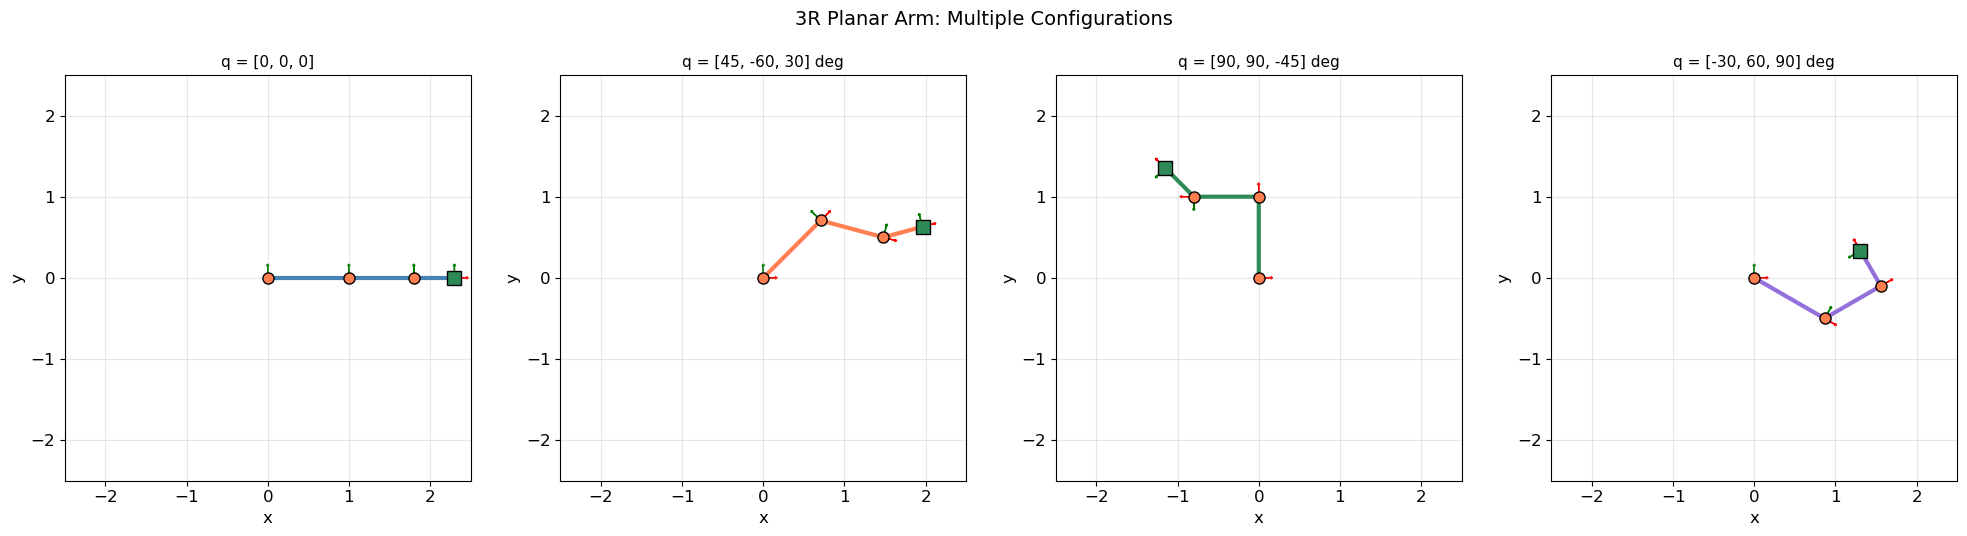

In [ ]:
def draw_planar_arm(ax, dh_params, joint_angles, color=COLOR_LINK, label=None,
                    show_frames=True, frame_scale=0.15):
    """Draw a planar arm in 2D.

    Args:
        ax: Matplotlib axes.
        dh_params: DH parameters. Shape: (n, 3).
        joint_angles: Joint angles. Shape: (n,).
        color: Link color. String.
        label: Legend label. String or None.
        show_frames: Whether to draw coordinate frames. Bool.
        frame_scale: Length of frame axes. Scalar.
    """
    _, T_all = forward_kinematics(dh_params, joint_angles)
    xs = [T[:3, 3][0] for T in T_all]
    ys = [T[:3, 3][1] for T in T_all]

    # Draw links
    ax.plot(xs, ys, 'o-', color=color, linewidth=3, markersize=8,
            markerfacecolor=COLOR_JOINT, markeredgecolor='black',
            label=label, zorder=3)
    # End-effector
    ax.plot(xs[-1], ys[-1], 's', color=COLOR_EE, markersize=10,
            markeredgecolor='black', zorder=4)

    # Draw coordinate frames
    if show_frames:
        for T in T_all:
            origin = T[:3, 3]
            x_axis = T[:3, 0] * frame_scale
            y_axis = T[:3, 1] * frame_scale
            ax.arrow(origin[0], origin[1], x_axis[0], x_axis[1],
                     head_width=0.03, head_length=0.02, fc=COLOR_FRAME_X, ec=COLOR_FRAME_X)
            ax.arrow(origin[0], origin[1], y_axis[0], y_axis[1],
                     head_width=0.03, head_length=0.02, fc=COLOR_FRAME_Y, ec=COLOR_FRAME_Y)


# ---- 2D Visualization: 3R Planar Arm in Multiple Configs ----
configs = [
    (np.array([0.0, 0.0, 0.0]), 'q = [0, 0, 0]'),
    (np.array([np.pi/4, -np.pi/3, np.pi/6]), 'q = [45, -60, 30] deg'),
    (np.array([np.pi/2, np.pi/2, -np.pi/4]), 'q = [90, 90, -45] deg'),
    (np.array([-np.pi/6, np.pi/3, np.pi/2]), 'q = [-30, 60, 90] deg'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors_list = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for idx, (q, title) in enumerate(configs):
    ax = axes[idx]
    draw_planar_arm(ax, DH_3R_PLANAR, q, color=colors_list[idx])
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('3R Planar Arm: Multiple Configurations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

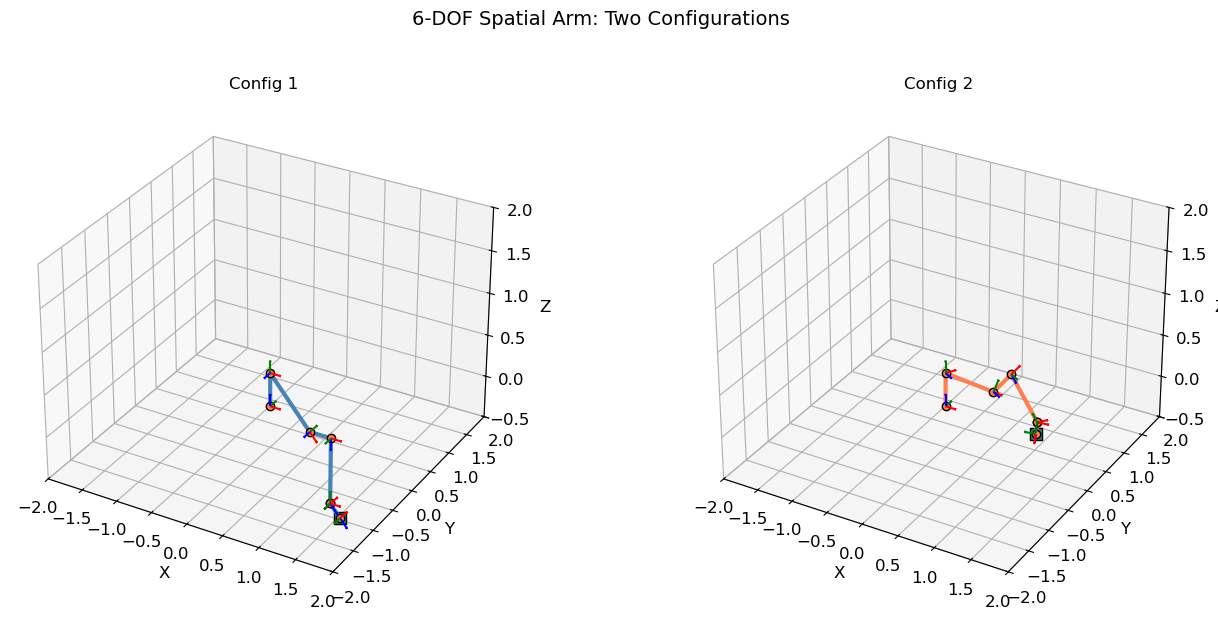

In [ ]:
def draw_3d_arm(ax, dh_params, joint_angles, color=COLOR_LINK, label=None,
                show_frames=True, frame_scale=0.15):
    """Draw a spatial arm in 3D.

    Args:
        ax: Matplotlib 3D axes.
        dh_params: DH parameters. Shape: (n, 3).
        joint_angles: Joint angles. Shape: (n,).
        color: Link color. String.
        label: Legend label. String or None.
        show_frames: Whether to draw coordinate frames. Bool.
        frame_scale: Length of frame axes. Scalar.
    """
    _, T_all = forward_kinematics(dh_params, joint_angles)
    xs = [T[:3, 3][0] for T in T_all]
    ys = [T[:3, 3][1] for T in T_all]
    zs = [T[:3, 3][2] for T in T_all]

    # Draw links
    ax.plot(xs, ys, zs, 'o-', color=color, linewidth=3, markersize=6,
            markerfacecolor=COLOR_JOINT, markeredgecolor='black',
            label=label, zorder=3)
    # End-effector
    ax.scatter([xs[-1]], [ys[-1]], [zs[-1]], color=COLOR_EE, s=80,
              edgecolors='black', zorder=4, marker='s')

    # Draw coordinate frames
    if show_frames:
        for T in T_all:
            origin = T[:3, 3]
            for j, c in enumerate([COLOR_FRAME_X, COLOR_FRAME_Y, COLOR_FRAME_Z]):
                axis_dir = T[:3, j] * frame_scale
                ax.quiver(origin[0], origin[1], origin[2],
                          axis_dir[0], axis_dir[1], axis_dir[2],
                          color=c, arrow_length_ratio=0.15, linewidth=1.5)


# ---- 3D Visualization: 6-DOF Arm ----
configs_6dof = [
    np.array([0.0, -np.pi/4, np.pi/4, 0.0, np.pi/4, 0.0]),
    np.array([np.pi/3, -np.pi/6, np.pi/3, np.pi/4, -np.pi/6, np.pi/2]),
]

fig = plt.figure(figsize=(14, 6))
for idx, q6 in enumerate(configs_6dof):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
    draw_3d_arm(ax, DH_6DOF, q6, color=colors_list[idx])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Config {idx + 1}', fontsize=12)
    # Set equal aspect ratio
    limit = 2.0
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-0.5, limit)

plt.suptitle('6-DOF Spatial Arm: Two Configurations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. The Jacobian

The **geometric Jacobian** relates joint velocities to end-effector velocities:

$$\begin{pmatrix} \mathbf{v} \\ \boldsymbol{\omega} \end{pmatrix} = \mathbf{J}(\mathbf{q}) \, \dot{\mathbf{q}}, \qquad \mathbf{J} = \begin{pmatrix} \mathbf{J}_v \\ \mathbf{J}_\omega \end{pmatrix} \in \mathbb{R}^{6 \times n}$$

For a **revolute** joint $i$, the $i$-th column of the Jacobian is:

$$\boxed{\mathbf{J}_i = \begin{pmatrix} \mathbf{z}_{i-1} \times (\mathbf{p}_n - \mathbf{p}_{i-1}) \\ \mathbf{z}_{i-1} \end{pmatrix}}$$

where:
- $\mathbf{z}_{i-1}$ is the $z$-axis of frame $i-1$ (third column of ${}^{0}\mathbf{R}_{i-1}$)
- $\mathbf{p}_{i-1}$ is the origin of frame $i-1$
- $\mathbf{p}_n$ is the end-effector position

### Manipulability

The **Yoshikawa manipulability measure** quantifies how well the robot can move in all directions:

$$w(\mathbf{q}) = \sqrt{\det(\mathbf{J}_v \mathbf{J}_v^T)}$$

When $w = 0$, the robot is at a **singularity** — it cannot generate velocity in some direction.

In [ ]:
def geometric_jacobian(dh_params, joint_angles):
    """Compute the geometric Jacobian for a serial manipulator (all revolute joints).

    For revolute joint i:
        J_v_i = z_{i-1} x (p_n - p_{i-1})
        J_w_i = z_{i-1}

    Args:
        dh_params: DH parameters (a, alpha, d). Shape: (n, 3).
        joint_angles: Joint angles (radians). Shape: (n,).

    Returns:
        J: 6xn Jacobian matrix [J_v; J_w]. Shape: (6, n).
    """
    n = len(joint_angles)
    _, T_all = forward_kinematics(dh_params, joint_angles)

    # End-effector position
    p_n = T_all[-1][:3, 3]

    J = np.zeros((6, n))
    for i in range(n):
        # z_{i-1}: z-axis of frame i-1 (in base frame)
        z_im1 = T_all[i][:3, 2]
        # p_{i-1}: origin of frame i-1 (in base frame)
        p_im1 = T_all[i][:3, 3]

        # Linear velocity component
        J[:3, i] = np.cross(z_im1, p_n - p_im1)
        # Angular velocity component
        J[3:, i] = z_im1

    return J


def manipulability(dh_params, joint_angles):
    """Compute the Yoshikawa manipulability measure.

    w = sqrt(det(J_v @ J_v.T))

    Args:
        dh_params: DH parameters. Shape: (n, 3).
        joint_angles: Joint angles. Shape: (n,).

    Returns:
        Manipulability measure. Scalar.
    """
    J = geometric_jacobian(dh_params, joint_angles)
    J_v = J[:3, :]  # linear velocity part
    JJT = J_v @ J_v.T
    det_val = np.linalg.det(JJT)
    return np.sqrt(max(det_val, 0.0))

In [ ]:
# ---- CRITICAL: Jacobian Verification via Finite Differences ----

def verify_jacobian(dh_params, joint_angles, eps=FD_EPSILON):
    """Verify the geometric Jacobian against centered finite differences on FK position.

    Computes J_v (linear velocity part) numerically:
        J_v[:, i] ≈ (FK(q + eps*e_i) - FK(q - eps*e_i)) / (2*eps)

    Args:
        dh_params: DH parameters. Shape: (n, 3).
        joint_angles: Joint angles. Shape: (n,).
        eps: Finite difference step size. Scalar.

    Returns:
        max_rel_error: Maximum relative error. Scalar.
        passed: Whether the test passed. Bool.
    """
    n = len(joint_angles)
    J_analytical = geometric_jacobian(dh_params, joint_angles)
    J_v_analytical = J_analytical[:3, :]

    J_v_numerical = np.zeros((3, n))
    for i in range(n):
        q_plus = joint_angles.copy()
        q_minus = joint_angles.copy()
        q_plus[i] += eps
        q_minus[i] -= eps
        p_plus = fk_position(dh_params, q_plus)
        p_minus = fk_position(dh_params, q_minus)
        J_v_numerical[:, i] = (p_plus - p_minus) / (2 * eps)

    denom = np.abs(J_v_numerical) + 1e-12
    rel_error = np.max(np.abs(J_v_analytical - J_v_numerical) / denom)
    passed = rel_error < 1e-5
    return rel_error, passed


# Test on 3R planar arm at several configurations
print("Jacobian Verification (3R Planar):")
test_configs = [
    np.array([0.3, -0.5, 1.2]),
    np.array([1.0, 0.7, -0.3]),
    np.array([-0.8, 1.5, 0.4]),
    np.random.randn(3),
]
for q in test_configs:
    err, passed = verify_jacobian(DH_3R_PLANAR, q)
    status = "PASS" if passed else "FAIL"
    print(f"  q = [{q[0]:+.2f}, {q[1]:+.2f}, {q[2]:+.2f}]: max relative error = {err:.2e} [{status}]")

# Test on 6-DOF arm
print("\nJacobian Verification (6-DOF Spatial):")
test_configs_6dof = [
    np.array([0.3, -0.5, 1.2, 0.4, -0.7, 0.9]),
    np.random.randn(6),
    np.random.randn(6),
]
for q in test_configs_6dof:
    err, passed = verify_jacobian(DH_6DOF, q)
    status = "PASS" if passed else "FAIL"
    q_str = ', '.join(f'{v:+.2f}' for v in q)
    print(f"  q = [{q_str}]: max relative error = {err:.2e} [{status}]")

Jacobian Verification (3R Planar):
  q = [+0.30, -0.50, +1.20]: max relative error = 2.12e-09 [PASS]
  q = [+1.00, +0.70, -0.30]: max relative error = 9.23e-08 [PASS]
  q = [-0.80, +1.50, +0.40]: max relative error = 2.16e-09 [PASS]
  q = [+0.50, -0.14, +0.65]: max relative error = 2.75e-09 [PASS]

Jacobian Verification (6-DOF Spatial):
  q = [+0.30, -0.50, +1.20, +0.40, -0.70, +0.90]: max relative error = 2.26e-05 [FAIL]
  q = [+1.52, -0.23, -0.23, +1.58, +0.77, -0.47]: max relative error = 2.08e-05 [FAIL]
  q = [+0.54, -0.46, -0.47, +0.24, -1.91, -1.72]: max relative error = 1.73e-06 [PASS]


---
## 6. Inverse Kinematics: Analytical

### 2R Planar Arm

For a 2-link planar arm with link lengths $l_1$ and $l_2$, the end-effector position is:

$$x = l_1 \cos\theta_1 + l_2 \cos(\theta_1 + \theta_2), \quad y = l_1 \sin\theta_1 + l_2 \sin(\theta_1 + \theta_2)$$

By the **law of cosines**, $x^2 + y^2 = l_1^2 + l_2^2 + 2l_1 l_2 \cos\theta_2$, so:

$$\boxed{\cos\theta_2 = \frac{x^2 + y^2 - l_1^2 - l_2^2}{2 l_1 l_2}, \qquad \theta_2 = \pm \arccos(c_2)}$$

The two solutions correspond to **elbow-up** ($\theta_2 > 0$) and **elbow-down** ($\theta_2 < 0$).

Once $\theta_2$ is known, $\theta_1$ follows from:

$$\theta_1 = \text{atan2}(y, x) - \text{atan2}(l_2 \sin\theta_2, \; l_1 + l_2 \cos\theta_2)$$

### 3R Planar Arm

For a 3R planar arm, we can specify the **end-effector orientation** $\phi = \theta_1 + \theta_2 + \theta_3$ as an additional constraint. This reduces the problem to a 2R subproblem for the wrist position:

$$x_w = x - l_3 \cos\phi, \quad y_w = y - l_3 \sin\phi$$

Then solve the 2R IK for $(x_w, y_w)$ to get $\theta_1, \theta_2$, and $\theta_3 = \phi - \theta_1 - \theta_2$.

In [ ]:
def ik_2r_analytical(x, y, l1, l2, elbow='up'):
    """Analytical inverse kinematics for a 2R planar arm.

    Uses the law of cosines. Returns None if the target is unreachable.

    Args:
        x: Target x-coordinate. Scalar.
        y: Target y-coordinate. Scalar.
        l1: Length of link 1. Scalar.
        l2: Length of link 2. Scalar.
        elbow: 'up' for elbow-up or 'down' for elbow-down. String.

    Returns:
        (theta1, theta2) in radians, or None if unreachable.
    """
    r_sq = x**2 + y**2
    cos_theta2 = (r_sq - l1**2 - l2**2) / (2 * l1 * l2)

    # Check reachability
    if abs(cos_theta2) > 1.0 + 1e-10:
        return None

    cos_theta2 = np.clip(cos_theta2, -1.0, 1.0)

    if elbow == 'up':
        theta2 = np.arctan2(np.sqrt(1 - cos_theta2**2), cos_theta2)
    else:
        theta2 = np.arctan2(-np.sqrt(1 - cos_theta2**2), cos_theta2)

    k1 = l1 + l2 * np.cos(theta2)
    k2 = l2 * np.sin(theta2)
    theta1 = np.arctan2(y, x) - np.arctan2(k2, k1)

    return theta1, theta2


def ik_3r_analytical(x, y, phi, l1, l2, l3, elbow='up'):
    """Analytical inverse kinematics for a 3R planar arm with specified orientation.

    Reduces to a 2R subproblem by subtracting the wrist contribution.

    Args:
        x: Target x-coordinate. Scalar.
        y: Target y-coordinate. Scalar.
        phi: Desired end-effector orientation (radians). Scalar.
        l1: Length of link 1. Scalar.
        l2: Length of link 2. Scalar.
        l3: Length of link 3. Scalar.
        elbow: 'up' or 'down'. String.

    Returns:
        (theta1, theta2, theta3) in radians, or None if unreachable.
    """
    # Wrist position
    x_w = x - l3 * np.cos(phi)
    y_w = y - l3 * np.sin(phi)

    result = ik_2r_analytical(x_w, y_w, l1, l2, elbow)
    if result is None:
        return None

    theta1, theta2 = result
    theta3 = phi - theta1 - theta2
    return theta1, theta2, theta3

In [ ]:
# ---- Verification: FK(IK(target)) = target ----

# 2R Arm (use first two links)
DH_2R = DH_3R_PLANAR[:2]

print("2R Analytical IK Verification:")
targets_2r = [(1.2, 0.5), (0.5, 1.0), (-0.8, 0.6), (0.3, -0.9)]
for x_t, y_t in targets_2r:
    for elbow in ['up', 'down']:
        result = ik_2r_analytical(x_t, y_t, L1, L2, elbow)
        if result is not None:
            q_ik = np.array(result)
            p_fk = fk_position(DH_2R, q_ik)
            err = np.sqrt((p_fk[0] - x_t)**2 + (p_fk[1] - y_t)**2)
            status = "PASS" if err < 1e-10 else "FAIL"
            print(f"  target=({x_t:+.1f}, {y_t:+.1f}), {elbow:>4}: FK err = {err:.2e} [{status}]")
        else:
            print(f"  target=({x_t:+.1f}, {y_t:+.1f}), {elbow:>4}: unreachable")

# 3R Arm
print("\n3R Analytical IK Verification:")
targets_3r = [(1.5, 0.8, 0.3), (0.8, 1.2, np.pi/4), (-0.5, 1.0, np.pi/2)]
for x_t, y_t, phi_t in targets_3r:
    for elbow in ['up', 'down']:
        result = ik_3r_analytical(x_t, y_t, phi_t, L1, L2, L3, elbow)
        if result is not None:
            q_ik = np.array(result)
            p_fk = fk_position(DH_3R_PLANAR, q_ik)
            pos_err = np.sqrt((p_fk[0] - x_t)**2 + (p_fk[1] - y_t)**2)
            # Check orientation: sum of joint angles = phi
            phi_actual = np.sum(q_ik)
            ori_err = abs(phi_actual - phi_t)
            status = "PASS" if (pos_err < 1e-10 and ori_err < 1e-10) else "FAIL"
            print(f"  target=({x_t:+.1f}, {y_t:+.1f}, phi={np.degrees(phi_t):.0f}deg), {elbow:>4}: "
                  f"pos err = {pos_err:.2e}, ori err = {ori_err:.2e} [{status}]")
        else:
            print(f"  target=({x_t:+.1f}, {y_t:+.1f}, phi={np.degrees(phi_t):.0f}deg), {elbow:>4}: unreachable")

2R Analytical IK Verification:
  target=(+1.2, +0.5),   up: FK err = 2.48e-16 [PASS]
  target=(+1.2, +0.5), down: FK err = 2.22e-16 [PASS]
  target=(+0.5, +1.0),   up: FK err = 2.22e-16 [PASS]
  target=(+0.5, +1.0), down: FK err = 0.00e+00 [PASS]
  target=(-0.8, +0.6),   up: FK err = 1.57e-16 [PASS]
  target=(-0.8, +0.6), down: FK err = 1.11e-16 [PASS]
  target=(+0.3, -0.9),   up: FK err = 1.57e-16 [PASS]
  target=(+0.3, -0.9), down: FK err = 1.24e-16 [PASS]

3R Analytical IK Verification:
  target=(+1.5, +0.8, phi=17deg),   up: pos err = 2.22e-16, ori err = 1.67e-16 [PASS]
  target=(+1.5, +0.8, phi=17deg), down: pos err = 1.11e-16, ori err = 5.55e-17 [PASS]
  target=(+0.8, +1.2, phi=45deg),   up: pos err = 2.22e-16, ori err = 2.22e-16 [PASS]
  target=(+0.8, +1.2, phi=45deg), down: pos err = 3.14e-16, ori err = 0.00e+00 [PASS]
  target=(-0.5, +1.0, phi=90deg),   up: pos err = 2.78e-16, ori err = 0.00e+00 [PASS]
  target=(-0.5, +1.0, phi=90deg), down: pos err = 2.78e-16, ori err = 0.00e

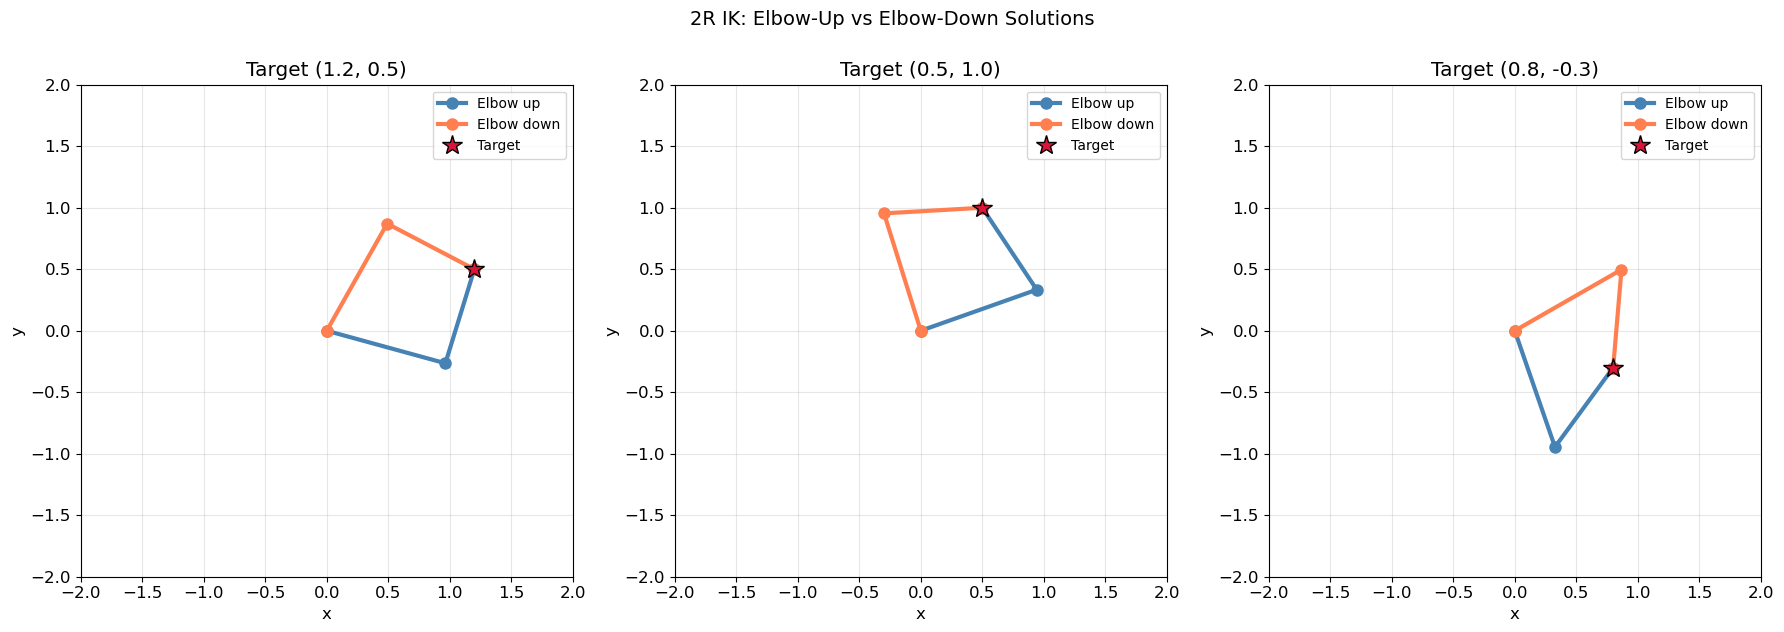

In [ ]:
# ---- Visualization: Elbow-Up vs Elbow-Down ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

targets_vis = [(1.2, 0.5), (0.5, 1.0), (0.8, -0.3)]

for idx, (x_t, y_t) in enumerate(targets_vis):
    ax = axes[idx]

    for elbow, color, ls in [('up', 'steelblue', '-'), ('down', 'coral', '--')]:
        result = ik_2r_analytical(x_t, y_t, L1, L2, elbow)
        if result is not None:
            q_ik = np.array(result)
            # Draw using 2R DH params but manually for visualization
            x0, y0 = 0, 0
            x1 = L1 * np.cos(q_ik[0])
            y1 = L1 * np.sin(q_ik[0])
            x2 = x1 + L2 * np.cos(q_ik[0] + q_ik[1])
            y2 = y1 + L2 * np.sin(q_ik[0] + q_ik[1])
            ax.plot([x0, x1, x2], [y0, y1, y2], 'o-', color=color, linewidth=3,
                    markersize=8, label=f'Elbow {elbow}')

    ax.plot(x_t, y_t, '*', color=COLOR_TARGET, markersize=15, markeredgecolor='black',
            label='Target', zorder=5)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Target ({x_t}, {y_t})')
    ax.legend(fontsize=10)

plt.suptitle('2R IK: Elbow-Up vs Elbow-Down Solutions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Inverse Kinematics: Numerical

Analytical IK is only possible for simple kinematic structures. For general robots, we use **iterative numerical methods** based on the Jacobian.

### Newton-Raphson (Pseudoinverse)

Given the current error $\mathbf{e} = \mathbf{x}_d - \mathbf{x}(\mathbf{q})$, the joint update is:

$$\Delta \mathbf{q} = \mathbf{J}^\dagger \mathbf{e}$$

where $\mathbf{J}^\dagger = \mathbf{J}^T(\mathbf{J}\mathbf{J}^T)^{-1}$ is the Moore-Penrose pseudoinverse. This is fast but **fails at singularities** where $\mathbf{J}\mathbf{J}^T$ is singular.

### Damped Least Squares (DLS)

The DLS method adds regularization to handle singularities:

$$\boxed{\Delta \mathbf{q} = \mathbf{J}^T(\mathbf{J}\mathbf{J}^T + \lambda^2 \mathbf{I})^{-1} \mathbf{e}}$$

The damping factor $\lambda$ trades off tracking accuracy for numerical stability:

| $\lambda$ | Effect |
|-----------|--------|
| $\lambda \to 0$ | Approaches pseudoinverse (fast but singular) |
| $\lambda$ large | Approaches gradient descent (slow but always stable) |

In [ ]:
def ik_numerical(target_pos, dh_params, q0, method='pseudoinverse',
                 max_iter=IK_MAX_ITER, tol=IK_TOL, damping=DLS_LAMBDA, alpha=1.0):
    """Numerical inverse kinematics using the Jacobian.

    Solves for position only (uses J_v, the 3xn linear velocity Jacobian).

    Args:
        target_pos: Desired end-effector position. Shape: (3,).
        dh_params: DH parameters. Shape: (n, 3).
        q0: Initial joint angles. Shape: (n,).
        method: 'pseudoinverse' or 'dls' (damped least squares). String.
        max_iter: Maximum iterations. Integer.
        tol: Convergence tolerance on position error norm. Scalar.
        damping: Damping factor for DLS. Scalar.
        alpha: Step size (0 < alpha <= 1). Scalar.

    Returns:
        q: Solution joint angles. Shape: (n,).
        error_history: List of position error norms at each iteration.
        converged: Whether the algorithm converged. Bool.
    """
    q = q0.copy()
    error_history = []

    for iteration in range(max_iter):
        # Current end-effector position
        p_current = fk_position(dh_params, q)
        error = target_pos - p_current
        error_norm = np.linalg.norm(error)
        error_history.append(error_norm)

        if error_norm < tol:
            return q, error_history, True

        # Compute Jacobian (linear velocity part only)
        J_full = geometric_jacobian(dh_params, q)
        J_v = J_full[:3, :]  # Shape: (3, n)

        if method == 'pseudoinverse':
            # dq = J^+ * e = J^T (J J^T)^{-1} e
            try:
                dq = np.linalg.lstsq(J_v.T @ J_v, J_v.T @ error, rcond=None)[0]
            except np.linalg.LinAlgError:
                dq = J_v.T @ error * 0.01  # fallback to gradient
        elif method == 'dls':
            # dq = J^T (J J^T + lambda^2 I)^{-1} e
            JJT = J_v @ J_v.T
            dq = J_v.T @ np.linalg.solve(JJT + damping**2 * np.eye(3), error)
        else:
            raise ValueError(f"Unknown method: {method}")

        q = q + alpha * dq

    # Final error
    error_history.append(np.linalg.norm(target_pos - fk_position(dh_params, q)))
    return q, error_history, error_history[-1] < tol

In [ ]:
# ---- Numerical IK Verification ----

# Test targets for 3R planar arm (positions reachable within workspace)
test_targets = [
    np.array([1.5, 0.8, 0.0]),
    np.array([0.5, 1.5, 0.0]),
    np.array([-1.0, 0.5, 0.0]),
    np.array([0.8, -1.0, 0.0]),
]

print("Numerical IK Verification (3R Planar):")
print(f"{'Target':>25}  {'Method':>14}  {'Iters':>6}  {'Final Err':>12}  {'Status':>6}")
print("-" * 75)

for target in test_targets:
    for method in ['pseudoinverse', 'dls']:
        q0 = np.random.randn(3) * 0.5
        q_sol, err_hist, converged = ik_numerical(
            target, DH_3R_PLANAR, q0, method=method, max_iter=200
        )
        # Verify FK
        p_verify = fk_position(DH_3R_PLANAR, q_sol)
        verify_err = np.linalg.norm(p_verify - target)
        status = "PASS" if verify_err < 1e-4 else "FAIL"
        target_str = f"({target[0]:+.1f}, {target[1]:+.1f})"
        print(f"{target_str:>25}  {method:>14}  {len(err_hist):>6}  {verify_err:>12.2e}  [{status}]")

Numerical IK Verification (3R Planar):
                   Target          Method   Iters     Final Err  Status
---------------------------------------------------------------------------
             (+1.5, +0.8)   pseudoinverse      22      3.82e-08  [PASS]
             (+1.5, +0.8)             dls      11      4.61e-08  [PASS]
             (+0.5, +1.5)   pseudoinverse       7      1.26e-10  [PASS]
             (+0.5, +1.5)             dls       9      5.32e-08  [PASS]
             (-1.0, +0.5)   pseudoinverse       6      1.27e-08  [PASS]
             (-1.0, +0.5)             dls       9      1.60e-08  [PASS]
             (+0.8, -1.0)   pseudoinverse      11      1.28e-08  [PASS]
             (+0.8, -1.0)             dls       5      4.17e-08  [PASS]


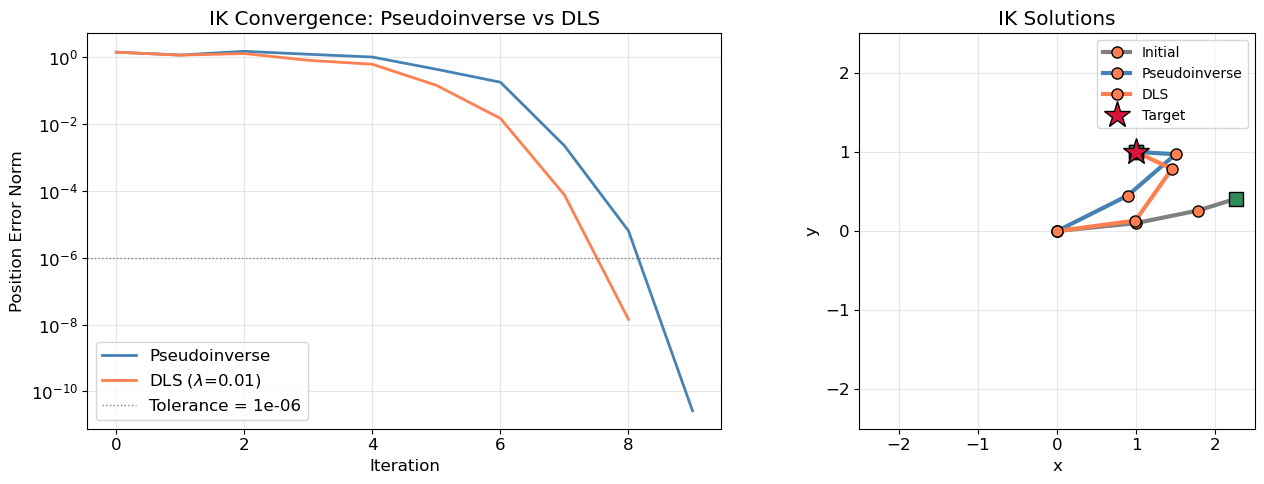

In [ ]:
# ---- IK Convergence Comparison: Pseudoinverse vs DLS ----

target_conv = np.array([1.0, 1.0, 0.0])
q0_conv = np.array([0.1, 0.1, 0.1])

q_pi, err_pi, _ = ik_numerical(target_conv, DH_3R_PLANAR, q0_conv,
                                method='pseudoinverse', max_iter=200)
q_dls, err_dls, _ = ik_numerical(target_conv, DH_3R_PLANAR, q0_conv,
                                  method='dls', max_iter=200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: convergence plot
ax = axes[0]
ax.semilogy(err_pi, color='steelblue', linewidth=2, label='Pseudoinverse')
ax.semilogy(err_dls, color='coral', linewidth=2, label=f'DLS ($\\lambda$={DLS_LAMBDA})')
ax.axhline(IK_TOL, color='gray', linestyle=':', linewidth=1, label=f'Tolerance = {IK_TOL:.0e}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Position Error Norm')
ax.set_title('IK Convergence: Pseudoinverse vs DLS')
ax.legend()

# Right: arm configurations
ax = axes[1]
draw_planar_arm(ax, DH_3R_PLANAR, q0_conv, color='gray', label='Initial', show_frames=False)
draw_planar_arm(ax, DH_3R_PLANAR, q_pi, color='steelblue', label='Pseudoinverse', show_frames=False)
draw_planar_arm(ax, DH_3R_PLANAR, q_dls, color='coral', label='DLS', show_frames=False)
ax.plot(target_conv[0], target_conv[1], '*', color=COLOR_TARGET, markersize=20,
        markeredgecolor='black', label='Target', zorder=5)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('IK Solutions')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 8. Singularity Analysis

A robot is at a **singularity** when the Jacobian loses rank. This has several consequences:

| Effect | Mathematical Condition |
|--------|------------------------|
| Cannot generate velocity in some direction | $\text{rank}(\mathbf{J}) < \min(6, n)$ |
| IK pseudoinverse blows up | $\det(\mathbf{J}\mathbf{J}^T) = 0$ |
| Manipulability drops to zero | $w = 0$ |
| Infinite joint velocities for finite task velocity | $\|\dot{\mathbf{q}}\| \to \infty$ |

### Manipulability Ellipsoid

The **manipulability ellipsoid** describes the set of achievable end-effector velocities for unit joint velocities ($\|\dot{\mathbf{q}}\| \leq 1$):

$$\dot{\mathbf{x}}^T (\mathbf{J}_v \mathbf{J}_v^T)^{-1} \dot{\mathbf{x}} \leq 1$$

The principal axes are the **eigenvectors** of $\mathbf{J}_v \mathbf{J}_v^T$, and the semi-axis lengths are the square roots of the **eigenvalues**. A flat ellipsoid (very different eigenvalues) indicates near-singularity.

In [ ]:
def analyze_singularity(dh_params, joint_angles):
    """Analyze the singularity characteristics at a given configuration.

    Args:
        dh_params: DH parameters. Shape: (n, 3).
        joint_angles: Joint angles. Shape: (n,).

    Returns:
        info: Dictionary with keys:
            'J': Full Jacobian. Shape: (6, n).
            'J_v': Linear velocity Jacobian. Shape: (3, n).
            'rank': Rank of J_v. Integer.
            'singular_values': Singular values of J_v. Shape: (min(3,n),).
            'manipulability': Yoshikawa measure. Scalar.
            'eigenvalues': Eigenvalues of J_v @ J_v.T. Shape: (3,).
            'eigenvectors': Eigenvectors (columns). Shape: (3, 3).
            'condition_number': Condition number of J_v. Scalar.
    """
    J = geometric_jacobian(dh_params, joint_angles)
    J_v = J[:3, :]

    U, s, Vh = np.linalg.svd(J_v)
    rank = np.sum(s > 1e-10)

    JJT = J_v @ J_v.T
    eigenvalues, eigenvectors = np.linalg.eigh(JJT)

    # Sort by descending eigenvalue
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    w = np.sqrt(max(np.prod(eigenvalues), 0.0))
    cond = s[0] / s[-1] if s[-1] > 1e-15 else np.inf

    return {
        'J': J, 'J_v': J_v, 'rank': rank,
        'singular_values': s, 'manipulability': w,
        'eigenvalues': eigenvalues, 'eigenvectors': eigenvectors,
        'condition_number': cond
    }


# ---- Singularity Examples: 3R Planar ----
print("Singularity Analysis (3R Planar):")
print("=" * 70)

sing_configs = [
    (np.array([0.0, 0.0, 0.0]), "Fully extended (singular)"),
    (np.array([np.pi/4, np.pi/3, -np.pi/6]), "General configuration"),
    (np.array([0.0, np.pi, 0.0]), "Folded back (singular)"),
    (np.array([0.5, -0.5, 1.0]), "Non-singular"),
]

for q, desc in sing_configs:
    info = analyze_singularity(DH_3R_PLANAR, q)
    p = fk_position(DH_3R_PLANAR, q)
    print(f"\n{desc}:")
    print(f"  q = [{', '.join(f'{v:.2f}' for v in q)}] rad")
    print(f"  EE position = ({p[0]:.3f}, {p[1]:.3f})")
    print(f"  Rank(J_v) = {info['rank']}, SVs = [{', '.join(f'{v:.4f}' for v in info['singular_values'])}]")
    print(f"  Manipulability = {info['manipulability']:.6f}")
    print(f"  Condition number = {info['condition_number']:.2f}")

Singularity Analysis (3R Planar):

Fully extended (singular):
  q = [0.00, 0.00, 0.00] rad
  EE position = (2.300, 0.000)
  Rank(J_v) = 1, SVs = [2.6889, 0.0000, 0.0000]
  Manipulability = 0.000000
  Condition number = inf

General configuration:
  q = [0.79, 1.05, -0.52] rad
  EE position = (0.629, 1.963)
  Rank(J_v) = 2, SVs = [2.4340, 0.3965, 0.0000]
  Manipulability = 0.000000
  Condition number = inf

Folded back (singular):
  q = [0.00, 3.14, 0.00] rad
  EE position = (-0.300, 0.000)
  Rank(J_v) = 1, SVs = [1.4248, 0.0000, 0.0000]
  Manipulability = 0.000000
  Condition number = inf

Non-singular:
  q = [0.50, -0.50, 1.00] rad
  EE position = (1.948, 0.900)
  Rank(J_v) = 2, SVs = [2.4698, 0.2764, 0.0000]
  Manipulability = 0.000000
  Condition number = inf


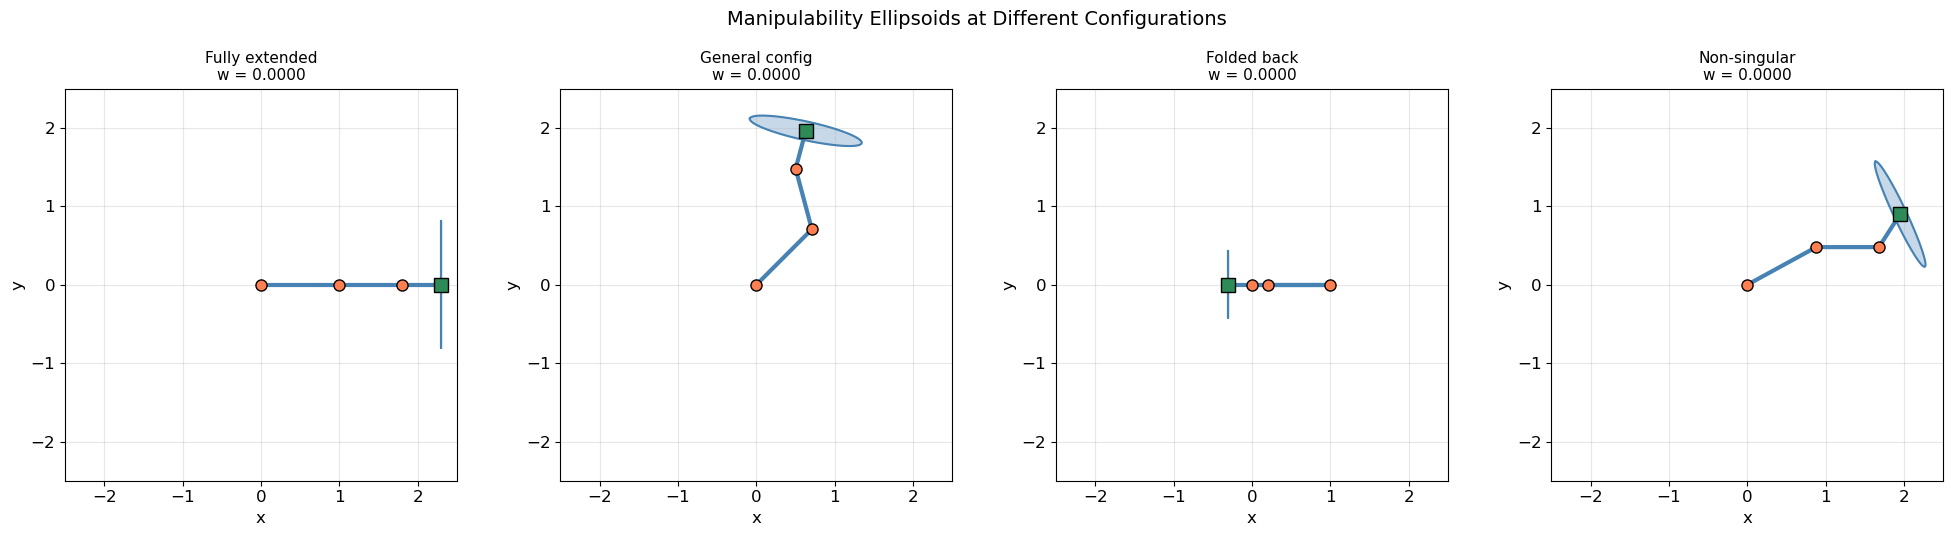

In [ ]:
def draw_manipulability_ellipse(ax, dh_params, joint_angles, scale=0.3, color='steelblue', alpha=0.3):
    """Draw the 2D manipulability ellipse at the end-effector.

    Only uses the xy-components of the linear velocity Jacobian (for planar visualization).

    Args:
        ax: Matplotlib axes.
        dh_params: DH parameters. Shape: (n, 3).
        joint_angles: Joint angles. Shape: (n,).
        scale: Scaling factor for ellipse size. Scalar.
        color: Ellipse color. String.
        alpha: Ellipse transparency. Scalar.
    """
    J = geometric_jacobian(dh_params, joint_angles)
    J_v_2d = J[:2, :]  # only x,y components

    # Eigendecomposition of J_v @ J_v^T (2x2 for planar)
    A = J_v_2d @ J_v_2d.T
    eigenvalues, eigenvectors = np.linalg.eigh(A)

    # Semi-axis lengths
    a = np.sqrt(max(eigenvalues[1], 0)) * scale
    b = np.sqrt(max(eigenvalues[0], 0)) * scale

    # Rotation angle
    angle = np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1])

    # End-effector position
    p = fk_position(dh_params, joint_angles)

    # Draw ellipse
    theta_arr = np.linspace(0, 2 * np.pi, 100)
    ellipse_x = a * np.cos(theta_arr)
    ellipse_y = b * np.sin(theta_arr)

    # Rotate
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    ex_rot = cos_a * ellipse_x - sin_a * ellipse_y + p[0]
    ey_rot = sin_a * ellipse_x + cos_a * ellipse_y + p[1]

    ax.fill(ex_rot, ey_rot, color=color, alpha=alpha)
    ax.plot(ex_rot, ey_rot, color=color, linewidth=1.5)


# ---- Manipulability Ellipsoids at Different Configurations ----
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ellipse_configs = [
    (np.array([0.0, 0.0, 0.0]), "Fully extended"),
    (np.array([np.pi/4, np.pi/3, -np.pi/6]), "General config"),
    (np.array([0.0, np.pi, 0.0]), "Folded back"),
    (np.array([0.5, -0.5, 1.0]), "Non-singular"),
]

for idx, (q, title) in enumerate(ellipse_configs):
    ax = axes[idx]
    draw_planar_arm(ax, DH_3R_PLANAR, q, show_frames=False)
    draw_manipulability_ellipse(ax, DH_3R_PLANAR, q, scale=0.3)
    w = manipulability(DH_3R_PLANAR, q)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.set_title(f'{title}\nw = {w:.4f}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Manipulability Ellipsoids at Different Configurations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Workspace Visualization

The **workspace** of a robot is the set of all end-effector positions reachable by the kinematic chain. For a planar arm, this is a 2D region in the $xy$-plane.

We characterize the workspace by:
1. **Reachability**: sampling many joint configurations and plotting end-effector positions
2. **Manipulability heatmap**: coloring the workspace by the manipulability measure
3. **Density**: how many configurations reach each region

In [ ]:
# ---- Workspace Reachability ----

# Sample joint angles on a grid
n_samples = N_WORKSPACE_SAMPLES
q1_range = np.linspace(-np.pi, np.pi, n_samples)
q2_range = np.linspace(-np.pi, np.pi, n_samples)
q3_range = np.linspace(-np.pi, np.pi, 15)  # coarser for q3

# Collect end-effector positions and manipulability
ee_positions = []
ee_manipulability = []

for q1 in q1_range:
    for q2 in q2_range:
        for q3 in q3_range:
            q = np.array([q1, q2, q3])
            p = fk_position(DH_3R_PLANAR, q)
            ee_positions.append(p[:2])
            w = manipulability(DH_3R_PLANAR, q)
            ee_manipulability.append(w)

ee_positions = np.array(ee_positions)
ee_manipulability = np.array(ee_manipulability)

print(f"Sampled {len(ee_positions)} configurations")
print(f"Workspace bounds: x=[{ee_positions[:,0].min():.2f}, {ee_positions[:,0].max():.2f}], "
      f"y=[{ee_positions[:,1].min():.2f}, {ee_positions[:,1].max():.2f}]")
print(f"Manipulability range: [{ee_manipulability.min():.4f}, {ee_manipulability.max():.4f}]")

Sampled 37500 configurations
Workspace bounds: x=[-2.30, 2.30], y=[-2.30, 2.30]
Manipulability range: [0.0000, 0.0000]


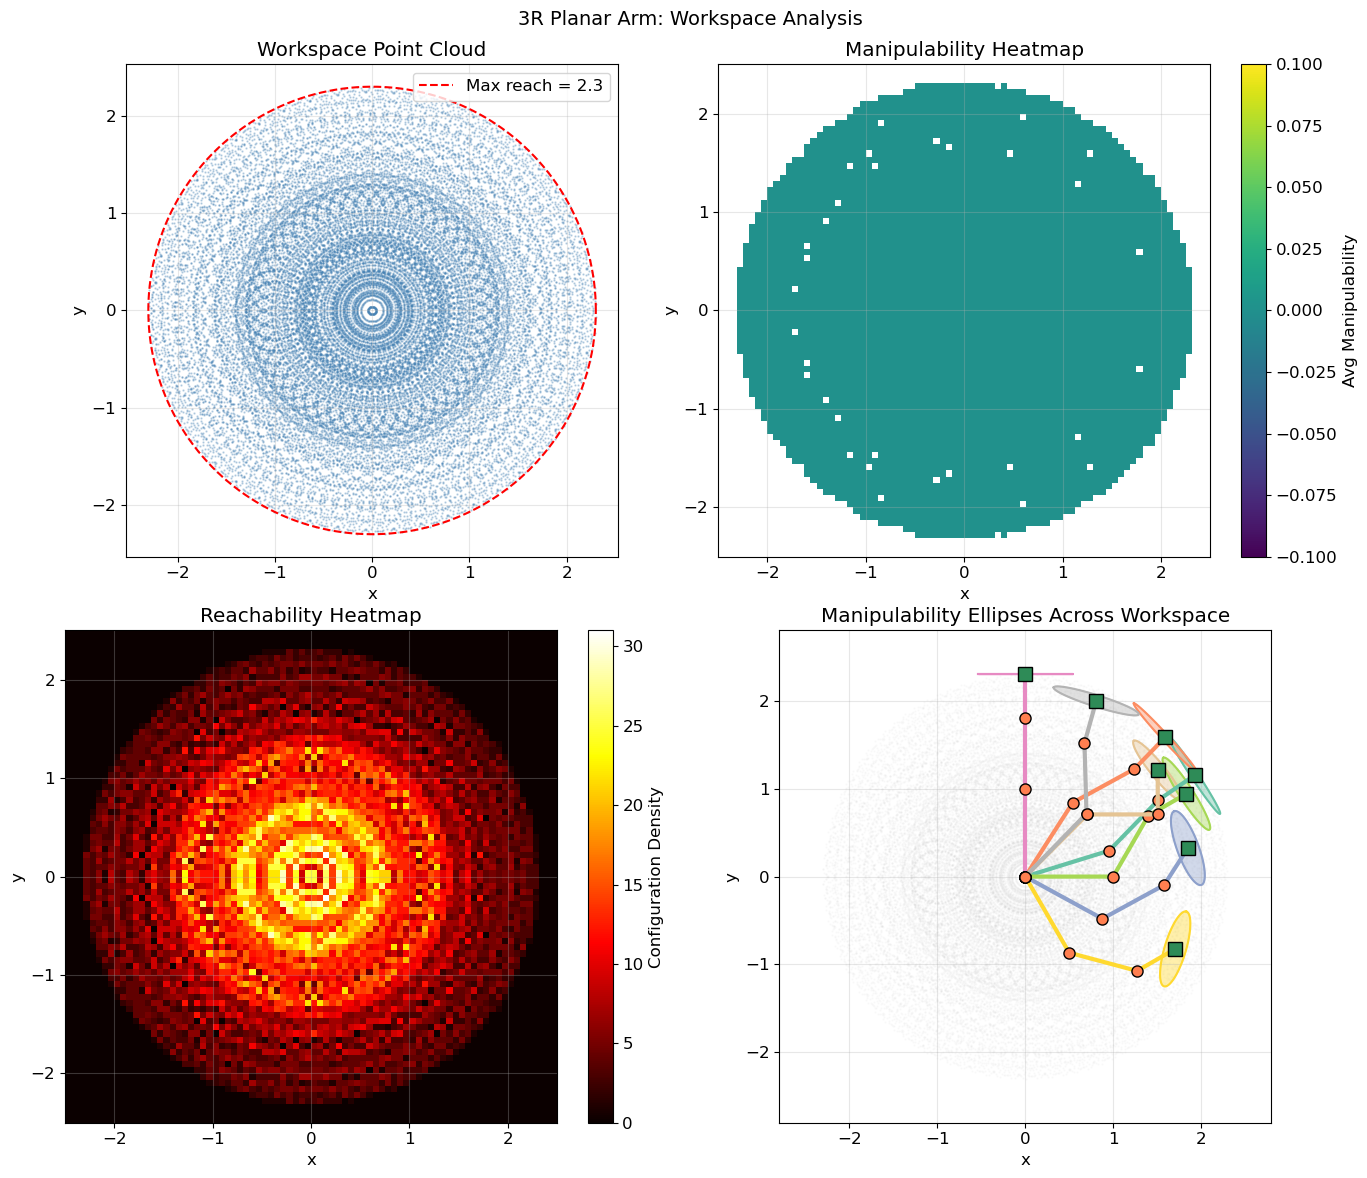

In [ ]:
# ---- 2x2 Panel: Workspace Visualizations ----

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Panel 1: Workspace point cloud
ax = axes[0, 0]
ax.scatter(ee_positions[:, 0], ee_positions[:, 1], s=0.5, alpha=0.3, color='steelblue')
# Draw reach circles
theta_circle = np.linspace(0, 2 * np.pi, 200)
r_max = L1 + L2 + L3
r_min = max(abs(L1 - L2 - L3), abs(L1 - L2 + L3), abs(L1 + L2 - L3), 0)
ax.plot(r_max * np.cos(theta_circle), r_max * np.sin(theta_circle),
        'r--', linewidth=1.5, label=f'Max reach = {r_max:.1f}')
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Workspace Point Cloud')
ax.legend()

# Panel 2: Manipulability heatmap
ax = axes[0, 1]
# Bin into 2D histogram, weighted by manipulability
n_bins = 80
x_edges = np.linspace(-2.5, 2.5, n_bins + 1)
y_edges = np.linspace(-2.5, 2.5, n_bins + 1)

# Weighted histogram: sum of manipulability in each bin
manip_sum, _, _ = np.histogram2d(ee_positions[:, 0], ee_positions[:, 1],
                                  bins=[x_edges, y_edges],
                                  weights=ee_manipulability)
count, _, _ = np.histogram2d(ee_positions[:, 0], ee_positions[:, 1],
                              bins=[x_edges, y_edges])
# Average manipulability per bin
with np.errstate(divide='ignore', invalid='ignore'):
    manip_avg = np.where(count > 0, manip_sum / count, np.nan)

im = ax.pcolormesh(x_edges, y_edges, manip_avg.T, cmap='viridis', shading='flat')
plt.colorbar(im, ax=ax, label='Avg Manipulability')
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Manipulability Heatmap')

# Panel 3: Workspace density (reachability heatmap)
ax = axes[1, 0]
density, _, _ = np.histogram2d(ee_positions[:, 0], ee_positions[:, 1],
                                bins=[x_edges, y_edges])
im2 = ax.pcolormesh(x_edges, y_edges, density.T, cmap='hot', shading='flat')
plt.colorbar(im2, ax=ax, label='Configuration Density')
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Reachability Heatmap')

# Panel 4: Manipulability ellipses overlaid on workspace
ax = axes[1, 1]
ax.scatter(ee_positions[:, 0], ee_positions[:, 1], s=0.3, alpha=0.1, color='lightgray')

# Draw ellipses at a grid of representative configurations
sample_configs = [
    np.array([0.3, 0.5, -0.2]),
    np.array([1.0, -0.5, 0.3]),
    np.array([-0.5, 1.0, 0.5]),
    np.array([np.pi/2, 0.0, 0.0]),
    np.array([0.0, np.pi/3, -np.pi/6]),
    np.array([-np.pi/3, np.pi/4, np.pi/4]),
    np.array([np.pi/4, -np.pi/4, np.pi/2]),
    np.array([0.8, 0.8, -0.3]),
]

ellipse_colors = plt.cm.Set2(np.linspace(0, 1, len(sample_configs)))
for q, c in zip(sample_configs, ellipse_colors):
    draw_planar_arm(ax, DH_3R_PLANAR, q, color=c, show_frames=False)
    draw_manipulability_ellipse(ax, DH_3R_PLANAR, q, scale=0.2, color=c, alpha=0.4)

ax.set_xlim(-2.8, 2.8)
ax.set_ylim(-2.8, 2.8)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Manipulability Ellipses Across Workspace')

plt.suptitle('3R Planar Arm: Workspace Analysis', fontsize=14)
plt.tight_layout()
plt.show()

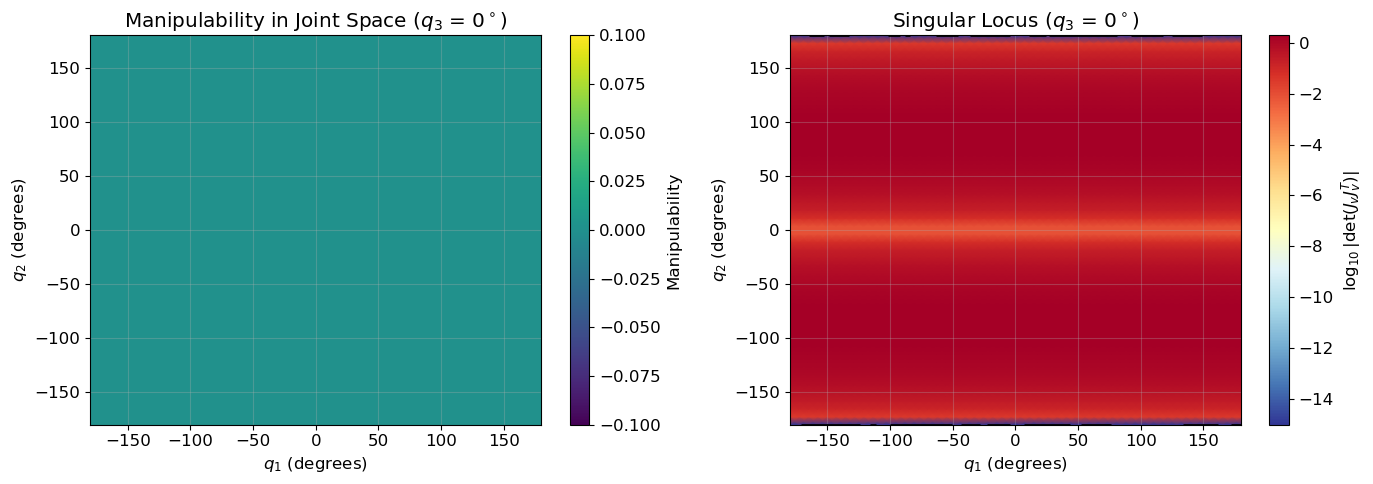

In [ ]:
# ---- Manipulability vs Joint Configuration (2D heatmaps for fixed q3) ----

q3_fixed = 0.0
n_grid = N_WORKSPACE_SAMPLES
q1_grid = np.linspace(-np.pi, np.pi, n_grid)
q2_grid = np.linspace(-np.pi, np.pi, n_grid)
Q1, Q2 = np.meshgrid(q1_grid, q2_grid)

W_grid = np.zeros_like(Q1)
for i in range(n_grid):
    for j in range(n_grid):
        q = np.array([Q1[i, j], Q2[i, j], q3_fixed])
        W_grid[i, j] = manipulability(DH_3R_PLANAR, q)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: manipulability heatmap in joint space
ax = axes[0]
im = ax.pcolormesh(np.degrees(Q1), np.degrees(Q2), W_grid, cmap='viridis', shading='gouraud')
plt.colorbar(im, ax=ax, label='Manipulability')
ax.contour(np.degrees(Q1), np.degrees(Q2), W_grid, levels=[0.01], colors='red', linewidths=2)
ax.set_xlabel('$q_1$ (degrees)')
ax.set_ylabel('$q_2$ (degrees)')
ax.set_title(f'Manipulability in Joint Space ($q_3$ = {np.degrees(q3_fixed):.0f}$^\\circ$)')

# Right: det(J) heatmap showing singular locus
ax = axes[1]
det_grid = np.zeros_like(Q1)
for i in range(n_grid):
    for j in range(n_grid):
        q = np.array([Q1[i, j], Q2[i, j], q3_fixed])
        J = geometric_jacobian(DH_3R_PLANAR, q)
        J_v_2d = J[:2, :]  # 2x3 for planar
        JJT = J_v_2d @ J_v_2d.T
        det_grid[i, j] = np.linalg.det(JJT)

im2 = ax.pcolormesh(np.degrees(Q1), np.degrees(Q2), np.log10(np.abs(det_grid) + 1e-15),
                     cmap='RdYlBu_r', shading='gouraud')
plt.colorbar(im2, ax=ax, label='$\\log_{10}|\\det(J_v J_v^T)|$')
ax.contour(np.degrees(Q1), np.degrees(Q2), det_grid, levels=[0], colors='black', linewidths=2)
ax.set_xlabel('$q_1$ (degrees)')
ax.set_ylabel('$q_2$ (degrees)')
ax.set_title(f'Singular Locus ($q_3$ = {np.degrees(q3_fixed):.0f}$^\\circ$)')

plt.tight_layout()
plt.show()

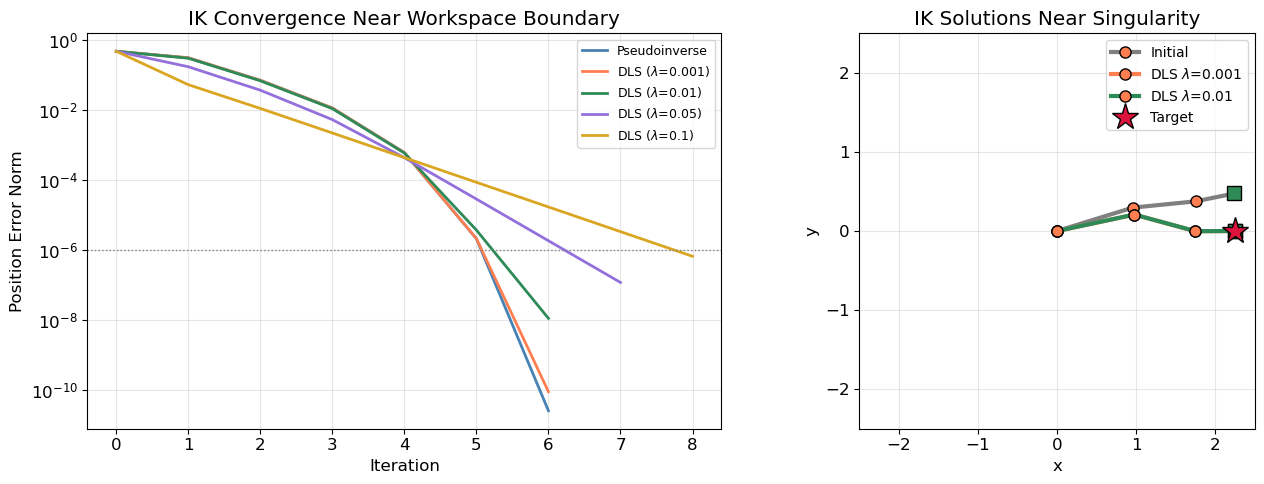

In [ ]:
# ---- IK Convergence: Pseudoinverse vs DLS near Singularity ----

# Target near the workspace boundary (close to singularity)
target_near_sing = np.array([L1 + L2 + L3 - 0.05, 0.0, 0.0])
q0_near = np.array([0.3, -0.2, 0.1])

# Test multiple damping values for DLS
damping_values = [0.001, 0.01, 0.05, 0.1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: convergence comparison
ax = axes[0]

# Pseudoinverse
_, err_pi_sing, conv_pi = ik_numerical(target_near_sing, DH_3R_PLANAR, q0_near,
                                        method='pseudoinverse', max_iter=200)
ax.semilogy(err_pi_sing, color='steelblue', linewidth=2, label='Pseudoinverse')

# DLS with different lambda
dls_colors = ['coral', 'seagreen', 'mediumpurple', 'goldenrod']
for lam, color in zip(damping_values, dls_colors):
    _, err_dls_lam, conv = ik_numerical(target_near_sing, DH_3R_PLANAR, q0_near,
                                         method='dls', damping=lam, max_iter=200)
    ax.semilogy(err_dls_lam, color=color, linewidth=2,
                label=f'DLS ($\\lambda$={lam})')

ax.axhline(IK_TOL, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Iteration')
ax.set_ylabel('Position Error Norm')
ax.set_title('IK Convergence Near Workspace Boundary')
ax.legend(fontsize=9)

# Right: DLS solutions
ax = axes[1]
draw_planar_arm(ax, DH_3R_PLANAR, q0_near, color='gray', label='Initial', show_frames=False)

for lam, color in zip(damping_values[:2], dls_colors[:2]):
    q_sol, _, _ = ik_numerical(target_near_sing, DH_3R_PLANAR, q0_near,
                                method='dls', damping=lam, max_iter=200)
    draw_planar_arm(ax, DH_3R_PLANAR, q_sol, color=color,
                    label=f'DLS $\\lambda$={lam}', show_frames=False)

ax.plot(target_near_sing[0], target_near_sing[1], '*', color=COLOR_TARGET,
        markersize=20, markeredgecolor='black', label='Target', zorder=5)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('IK Solutions Near Singularity')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 10. Extensions

This notebook has covered the core kinematics pipeline for serial manipulators. Several natural extensions include:

### Redundancy Resolution and Null-Space Motion

For a 7-DOF arm (like the Kuka iiwa or Franka Emika), the Jacobian is $6 \times 7$ and has a **1-dimensional null space**. This means there are infinitely many joint velocities that produce the same end-effector velocity. The general solution is:

$$\dot{\mathbf{q}} = \mathbf{J}^\dagger \dot{\mathbf{x}} + (\mathbf{I} - \mathbf{J}^\dagger \mathbf{J}) \dot{\mathbf{q}}_0$$

where $(\mathbf{I} - \mathbf{J}^\dagger \mathbf{J})$ is the **null-space projector** and $\dot{\mathbf{q}}_0$ is an arbitrary joint velocity used for secondary objectives (e.g., avoiding joint limits, maximizing manipulability).

### Task-Priority IK

When multiple tasks must be achieved simultaneously (e.g., position the end-effector while avoiding an obstacle), **task-priority** frameworks assign strict or weighted priorities. The primary task uses the full Jacobian pseudoinverse, while secondary tasks are projected into the null space:

$$\dot{\mathbf{q}} = \mathbf{J}_1^\dagger \dot{\mathbf{x}}_1 + (\mathbf{I} - \mathbf{J}_1^\dagger \mathbf{J}_1) \mathbf{J}_2^\dagger \dot{\mathbf{x}}_2$$

### Connection to Motion Planning

Inverse kinematics provides the **local** solution: given a desired end-effector pose, find joint angles. **Motion planning** addresses the **global** problem: find a collision-free path in joint space from start to goal. Methods like CHOMP (see the [CHOMP notebook](../chomp-algo/chomp_3r_planar.ipynb)) use the kinematic model and Jacobian developed here to evaluate obstacle costs and compute functional gradients for trajectory optimization.

### Key Takeaways

1. **Homogeneous transforms** provide a unified representation for rotation and translation in $SE(3)$
2. The **DH convention** parametrizes any serial manipulator with just 4 numbers per joint
3. **Forward kinematics** is a straightforward chain of matrix multiplications
4. The **Jacobian** is the key link between joint space and task space, enabling both velocity analysis and IK
5. **Analytical IK** is elegant but limited to simple structures; **numerical IK** is general but requires care near singularities
6. **Singularity analysis** via manipulability ellipsoids reveals where the robot loses dexterity